# Test file for Propp-Wilson CFTP algorithm on Curie-Weiss model
-----

This file is made to test and write codes and computations about the bouding chain methods for implementing the CFTP algorithm. 

We first implement the classical Metropolis-Hasting (in fact Gibbs) MCMC algorithm for the usual mean-field Ising model (i.e. the Curie-Weiss model).

We then implement the same CFTP algorithm but using monotonicity to determine the coupling time $\tau$.

Then, we compare physics observables obtained from the CFTP with the monotocity method, classical Metropolis-Hasting algorithm and analytical predictions.


Some notation :
We denote $\underline\sigma\in\{-1,+1\}^n$ a configuration of the CW model. Its Hamiltonian is given by 

$$ H[\underline\sigma] = -\frac{1}{2N}\sum_{i,j=1}^N\sigma(i)\sigma(j) $$

at zero external magnetic field and $J=1$ constant ferromagnetic interaction. We denote $p_{GB}(\underline\sigma; \beta) = \frac{e^{-\beta H[\underline\sigma]}}{\sum_{\underline\sigma}e^{-\beta H[\underline \sigma]}}=\frac1Ze^{-\beta H[\underline\sigma]}$ the Gibbs-Boltzman measure associated to the system.

In [9]:
##### CLASSICAL METROPOLIS-HASTINGS ALGORITHM FOR MEAN-FIELD ISING MODEL #####

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# configuration of matplotlib for better visualization and paper-quality figures
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 22,
    'lines.linewidth': 4,
    'axes.grid': True,
    'legend.fontsize': 12,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.markersize': 10,
    'font.family': 'serif',
    'font.serif': ['Latin Modern Roman'],
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    # remove the box around the legend
    'legend.frameon': False
})

Text(0, 0.5, 'Magnetization')

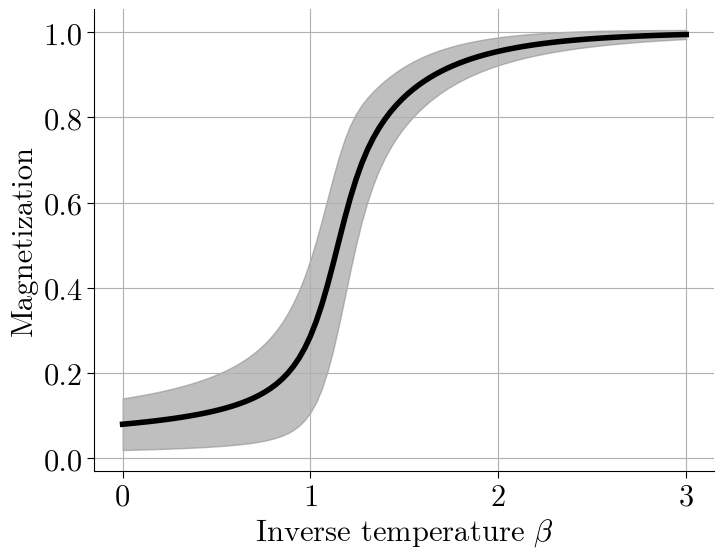

In [10]:
from scipy.special import factorial

def partition_function(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  # Possible magnetization values
    Z = 0
    for m in val_m:
        km = N/2*(1+m)  # Number of +1 spins
        prefac = factorial(N) / (factorial(km) * factorial(N - km))
        energy = -N * m**2 / 2 
        Z += prefac * np.exp(-beta * energy)
    return Z

def theoretical_magnetization(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  # Possible magnetization values
    mag_sum = 0
    for m in val_m:
        km = N/2*(1+m)  # Number of +1 spins
        prefac = factorial(N) / (factorial(km) * factorial(N - km))
        energy = -N * m**2 / 2 
        mag_sum += prefac * np.abs(m) * np.exp(-beta * energy)
    return mag_sum/partition_function(beta, N)

def theoretical_magnetization_variance(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  # Possible magnetization values
    mean_mag = 0
    mean_mag_square = 0
    for m in val_m:
        km = N/2*(1+m)  # Number of +1 spins
        prefac = factorial(N) / (factorial(km) * factorial(N - km))
        energy = -N * m**2 / 2  # Energy per particle
        mean_mag += prefac * np.abs(m) * np.exp(-beta * energy)
        mean_mag_square += prefac * np.abs(m)**2 * np.exp(-beta * energy)
    mean_mag = mean_mag/partition_function(beta, N)
    mean_mag_squared = mean_mag_square/partition_function(beta, N)
    return mean_mag_squared - mean_mag**2

# Analytical results for the theoretical absolute magnetization (i.e. spontaneous magnetization assuming $h\to 0^+$) and its variance

N = 100
beta = np.linspace(0, 3.0, 100)
theoretical_magnetizations = [theoretical_magnetization(b, N) for b in beta]
theoretical_magnetization_variances = [theoretical_magnetization_variance(b, N) for b in beta]
plt.figure(1)
plt.plot(beta, theoretical_magnetizations, 'k-')
plt.fill_between(beta, theoretical_magnetizations - np.sqrt(theoretical_magnetization_variances), theoretical_magnetizations + np.sqrt(theoretical_magnetization_variances), color='gray', alpha=0.5, label='Magnetization Variance')
plt.xlabel(r'Inverse temperature $\beta$')
plt.ylabel('Magnetization')

In [11]:
def Glauber_heat_bath(n, beta, num_iterations):
    x = np.random.choice([-1, 1], size=n) # Random init
    for _ in range(num_iterations):
        i = np.random.randint(n)  # Randomly select a spin
        h_eff = np.sum(x) - x[i]  # Effective field from other spins
        p_up = 1 / (1 + np.exp(-2 * beta * h_eff/n))  # Probability of spin being +1
        x[i] = 1 if np.random.rand() < p_up else -1  # Update spin based on probability
    m = np.abs(np.mean(x))
    return m

# Parameters
N = 100  # Number of spins
n_iter = 10000  # Number of iterations

# Simulate for different values of beta
avg_magnetizations = []
for b in tqdm(beta):
    m = []
    for _ in range(10):  # Run multiple simulations to average results
        m_i = Glauber_heat_bath(N, b, n_iter)
        m.append(m_i)
    avg_m = np.mean(m)
    avg_magnetizations.append(avg_m)

100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


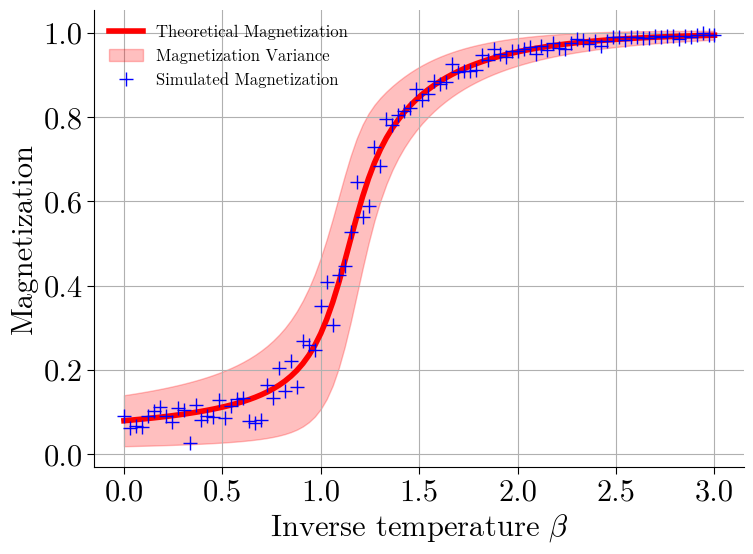

In [12]:
plt.plot(beta, theoretical_magnetizations, 'r-', label='Theoretical Magnetization')
plt.fill_between(beta, theoretical_magnetizations - np.sqrt(theoretical_magnetization_variances), theoretical_magnetizations + np.sqrt(theoretical_magnetization_variances), color='red', alpha=0.25, label='Magnetization Variance')
plt.plot(beta, avg_magnetizations, 'b+', label='Simulated Magnetization')
plt.xlabel(r'Inverse temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.tight_layout()
plt.show()

## CFTP test

We use the following update function for the extremal Markov Chains use in the monotonicity method :

$$
\underline\sigma_{n+1}(i) = \left\lbrace \begin{matrix} +1, \text{ if } U_{n+1} < p_{GB}(\sigma(i)=+1 | \underline\sigma-\sigma(i) = \underline\sigma_n-\sigma(i)) \\ -1,\text{ else}\\ \end{matrix}\right.
$$

Where $\underline\sigma-\sigma(i)$ indicates that we are blind to the value of $\sigma(i)$ (i.e. we keep all the rest of the configuration as it was at time step $n$ but do not care about the value of $\sigma(i)$.). The conditional probability is easy to compute explicitely. Using Bayes' rule we have $p_{GB}(\sigma(i)=+1 | \underline\sigma-\sigma(i) = \underline\sigma_n-\sigma(i))  = \frac{p_{GB}(\sigma(i)=+1, \underline\sigma-\sigma(i) = \underline\sigma_n-\sigma(i))}{p_{GB}(\underline\sigma-\sigma(i) = \underline\sigma_n-\sigma(i))} $. The denominator is simply $p_{GB}(\underline\sigma-\sigma(i) = \underline\sigma_n-\sigma(i))=p_{GB}[\underline\sigma_n, \sigma_n(i)=+1] + p_{GB}[\underline\sigma_n, \sigma_n(i)=-1]$.

Therefore, using what preceed and the expression of $p_{GB}$, it is easy to compute that :

$$ p_{GB}(\sigma(i)=+1 | \underline\sigma-\sigma(i) = \underline\sigma_n-\sigma(i)) = \frac1{1+\exp\left(-\frac{2\beta}N \sum_{k\neq i}\sigma(k)\right)} $$

In [13]:
"""
Now we want to use the Coupling From The Past (CFTP) algorithm to sample from the stationary distribution of the Markov chain defined by the Metropolis-Hastings updates. The idea is to run multiple chains backward in time until they coalesce into a single configuration, which will be a perfect sample from the stationary distribution. We will use the sandwiching technique in order to efficiently determine when coalescence has occurred. This involves maintaining upper and lower bounding chains that evolve according to the same random updates, and checking when they meet.
"""

"""
CFTP algorithm in pseudocode:
1. Initialize two bounding chains: an upper chain starting from the all +1 configuration and a lower chain starting from the all -1 configuration.
2. For each time step t in (1, 2, 4, 8, ...):
    a. Generate a random update (e.g., which spin to flip and whether to accept the flip) that would be applied to any chain at time t.
"""

def CFTP(beta, N):
    times = np.array([2**i for i in range(18)])
    # Initialize bounding chains
    randoms = []  # To store random numbers for updates
    random_nodes = []  
    for m in range(len(times)):
        t = -times[m]
        upper_chain = np.ones(N, dtype=int)  # All +1 configuration
        lower_chain = -np.ones(N, dtype=int)  # All -1 configuration
        for n in range(t, 1): # number of iterations to run the chains in the past to the present t=0
            while len(randoms) < -t:
                randoms.append(np.random.rand())  # Generate random numbers for updates
                random_nodes.append(np.random.randint(N))  
            actual_random_number = randoms[-n-1]  # Get the random number for this iteration (always use the same random at fixed time step)
            actual_random_node = random_nodes[-n-1]  
            # Update both chains according to the same random update

            # Upper chain
            S_minus_i_upper = np.sum(upper_chain) - upper_chain[actual_random_node]
            # Conditional probability of being +1
            proba_plus_upper = 1.0 / (1.0 + np.exp(-2.0 * beta * S_minus_i_upper / N)) # comes from computing the conditional
            if actual_random_number < proba_plus_upper:
                upper_chain[actual_random_node] = 1
            else:
                upper_chain[actual_random_node] = -1
            
            # Lower chain
            S_minus_i_lower = np.sum(lower_chain) - lower_chain[actual_random_node]
            proba_plus_lower = 1.0 / (1.0 + np.exp(-2.0 * beta * S_minus_i_lower / N))
            
            if actual_random_number < proba_plus_lower:
                lower_chain[actual_random_node] = 1
            else:
                lower_chain[actual_random_node] = -1
        
        # Check for coalescence
        if np.array_equal(upper_chain, lower_chain):
            mag = np.mean(upper_chain)
            abs_mag = np.abs(mag)  # Absolute magnetization
            return upper_chain, abs_mag, times[m]
            
    print("Failed to coalesce within maximum time steps.")
    return None, np.nan, times[-1]

100%|██████████| 100/100 [00:55<00:00,  1.81it/s]


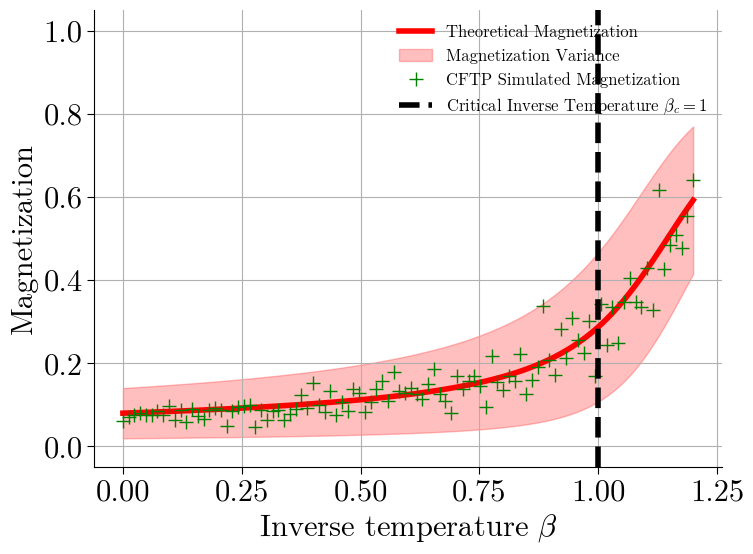

In [14]:
N = 100
beta_cftp = np.linspace(0, 1.2, 100)
theoretical_magnetizations_cftp = [theoretical_magnetization(b, N) for b in beta_cftp]
theoretical_magnetization_variances_cftp = [theoretical_magnetization_variance(b, N) for b in beta_cftp]
avg_magnetizations_cftp = []
for b in tqdm(beta_cftp):
    m_temp = []
    for _ in range(10):  # Run multiple simulations to average results
        _, m, _ = CFTP(b, N)
        m_temp.append(m)
    avg_magnetizations_cftp.append(np.nanmean(m_temp))

plt.plot(beta_cftp, theoretical_magnetizations_cftp, 'r-', label='Theoretical Magnetization')
plt.fill_between(beta_cftp, theoretical_magnetizations_cftp - np.sqrt(theoretical_magnetization_variances_cftp), theoretical_magnetizations_cftp + np.sqrt(theoretical_magnetization_variances_cftp), color='red', alpha=0.25, label='Magnetization Variance')
plt.plot(beta_cftp, avg_magnetizations_cftp, 'g+', label='CFTP Simulated Magnetization')
plt.vlines(1.0, -0.05, 1.05, color='k', linestyle='--', label=r'Critical Inverse Temperature $\beta_c=1$')
plt.ylim(-0.05, 1.05)
plt.xlabel(r'Inverse temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.tight_layout()
plt.show()

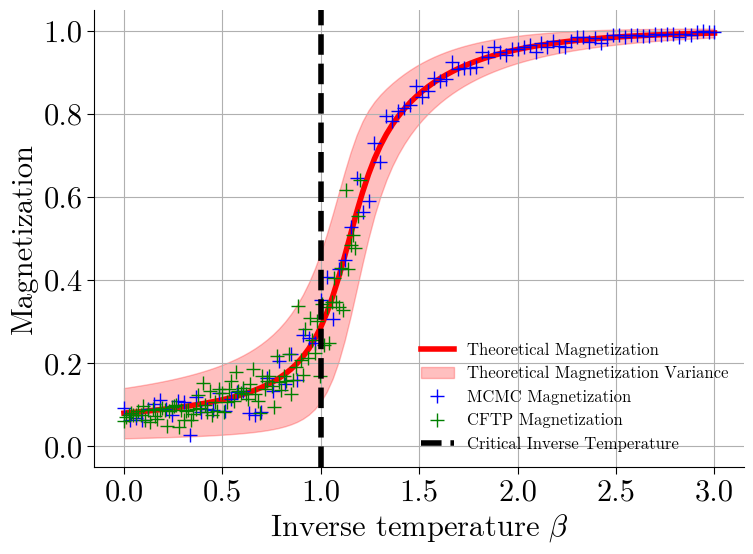

In [ ]:
## Finally plot of classical MCMC results with theoretical predictions and CFTP results for comparison
plt.plot(beta, theoretical_magnetizations, 'r-', label='Theoretical Magnetization')
plt.fill_between(beta, theoretical_magnetizations - np.sqrt(theoretical_magnetization_variances), theoretical_magnetizations + np.sqrt(theoretical_magnetization_variances), color='red', alpha=0.25, label='Theoretical Magnetization Variance')
plt.plot(beta, avg_magnetizations, 'b+', label='MCMC Magnetization')
plt.plot(beta_cftp, avg_magnetizations_cftp, 'g+', label='CFTP Magnetization')
plt.vlines(1.0, -0.05, 1.05, color='k', linestyle='--', label=r'Critical Inverse Temperature')
plt.ylim(-0.05, 1.05)
plt.xlabel(r'Inverse temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.tight_layout()
plt.savefig('CW_magnetization_comparison.png')
plt.show()